## Preparation

In [34]:
# Updated Version

import os
import re
import pandas as pd
from ase.io import read, write
from ase import Atoms
import numpy as np
import random as r
import sys
from collections import defaultdict, deque

def near(atomnum, atoms, tolerance=2.000, Cfirst=True):
    atoms_not_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
    mole = [atomnum]
    pre_distances = atoms.get_distances(atomnum, atoms_not_H)
    distances = np.delete(pre_distances, np.where(pre_distances >= tolerance))
    distances = np.delete(distances, np.where(distances == 0))
    distances.sort()
    length = len(distances)
    if length > 4:
        distances = distances[:4]
    for i, atom in enumerate(atoms_not_H):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            mole.append(atom)
    mole_C = []
    mole_other = []
    for num in mole:
        if atoms[num].symbol == 'C':
            mole_C.append(num)
        else:
            mole_other.append(num)
    if len(distances) == 1:
        if atoms[atomnum].symbol == 'C':
            return mole_C + mole_other
        else:
            return mole_other + mole_C
    if Cfirst == True:
        return mole_C + mole_other
    else:
        return mole_other + mole_C

def allone(lists):
    judge_box = []
    for ls in lists:
        for i in ls:
            judge_box.append(i)
    if 0 in judge_box:
        return 0
    else:
        return 1

def allroutes(file, loc='./', atomnums=[0,1], tolerance=2.000,\
              form='XYZ', Cfirst=True, ignores=[], verbose=False):
    passeds = []
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    atomnum1 = atomnums[0]
    atomnum2 = atomnums[1]
    atoms_not_H = []
    atoms_H = []
    for i, atom in enumerate(atoms):
        if atom.symbol != 'H':
            atoms_not_H.append(i)
        else:
            atoms_H.append(i)
    
    #Trace Back
    step = 1
    z = 1
    i = 1
    passed = []
    routes = []
    real_moles = []
    route = [atomnum1]
    while 1:
        mole = near(atomnum1, atoms, tolerance=tolerance, Cfirst=Cfirst)
        if verbose == True:
            print('Near:', mole)
        real_mole = [*mole]
        real_mole.remove(atomnum1)
        real_moles.append(real_mole)
        passed = [0]*len(real_mole)
        passeds.append(passed)
        
        if verbose == True:
            print(1)
            print('Real Near:', real_mole)
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        for i,p in enumerate(passeds[step-1]):
            if real_moles[step-1][i] in ignores:
                passeds[step-1][i] = 1
            if real_moles[step-1][i] in route:
                passeds[step-1][i] = 1
        
        if allone(passeds) == 1:
            break
        
        while 0 not in passeds[step-1]:
            del passeds[-1]
            step = step - 1
            del route[-1]
            del real_moles[-1]
        
        for j, p in enumerate(passeds[step-1]):
            if p == 0:
                break
        
        passeds[step-1][j] = 1
        atomnum1 = real_moles[step-1][j]
        route.append(atomnum1)
        if verbose == True:
            print(2)
            print('Real Near:', real_moles[step-1])
            print('Passed:', passeds)
            print('Number:', real_moles)
            print('Route:', route)
            print()
        
        if route[-1] == atomnum2:
            print('\nCorrect Route:', route)
            routes.append([*route])
            print('\n')
        
        step = step + 1

        z = z + 1
    if verbose == True:
        print(z, 'steps to find these routes.')
        print('Routes:', routes)
    os.chdir(opath)
    return routes

def routelength(file, a, loc='./'):
    opath = os.getcwd()
    os.chdir(loc)
    atoms = read(file+'.xyz')
    distance = 0
    for i in range(len(a)-1):
        x1 = a[0]
        x2 = a[1]
        distance = distance + atoms.get_distances(x1, x2)[0]
    os.chdir(opath)
    return distance

In [35]:
def near_notH(atomnum, atoms, tolerance=1.7):
    atoms_not_7 = []
    for i, atom in enumerate(atoms):
        if atom.symbol not in ['H', 'F', 'Cl', 'Br']:
            atoms_not_7.append(i)
    mole = []
    mole_ele = []
    pre_distances = atoms.get_distances(atomnum, atoms_not_7)
    distances = np.delete(pre_distances, np.where(pre_distances == 0))
    distances.sort()
    length = len(distances)
    distances = distances[:4]
    for i, atom in enumerate(atoms_not_7):
        distance = atoms.get_distance(atom, atomnum)
        if distance in distances:
            ele1 = atoms.get_chemical_symbols()[atom]
            ele2 = atoms.get_chemical_symbols()[atomnum]
            if 'S' in [ele1, ele2]:
                if distance < tolerance + 0.45:
                    mole.append([atomnum, atom])
                    mole_ele.append([ele2, ele1])
            else:
                if distance < tolerance:
                    mole.append([atomnum, atom])
                    mole_ele.append([ele2, ele1])
    return mole, mole_ele

def all_bonds(atoms, tolerance=1.7):
    atoms_not_7 = []
    Bs = []
    Bs_ele = []
    for i, atom in enumerate(atoms):
        if atom.symbol not in ['H', 'F', 'Cl', 'Br']:
            atoms_not_7.append(i)
    for atomnum in atoms_not_7:
        mole, mole_ele = near_notH(atomnum, atoms, tolerance=tolerance)
        for dipole in mole:
            pre_dipole = [*dipole]
            dipole.sort()
            if dipole != pre_dipole:
                mole_ele.reverse()
            if dipole not in Bs:
                Bs.append(dipole)
                Bs_ele.append(mole_ele)
    return Bs, Bs_ele

In [36]:
def num_in_ring(num, ringsize):
    if num < ringsize:
        return num
    else:
        return num - ringsize

def classify_nodes_by_cycles(n, edges, atoms, simplerings=True):
    # Find all rings
    adj = [[] for _ in range(n)]
    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)
    
    all_cycles = []
    all_cycles_hide = []
    conjs = []
    visited_global = [False] * n
    #print('adj =', adj)
    
    def find_simple_cycles(start):
        visited_local = [False] * n
        stack = []
        
        def dfs(node, depth, min_node):
            visited_local[node] = True
            stack.append(node)
            
            for neighbor in adj[node]:
                if neighbor < min_node:
                    continue
                    
                if neighbor == start and depth >= 2:
                    
                    cycle = stack[:] + [start]
                    
                    min_idx = cycle.index(min(cycle))
                    normalized = tuple(cycle[min_idx:] + cycle[:min_idx])
                    if {*normalized} not in all_cycles_hide:
                        all_cycles.append(normalized)
                        all_cycles_hide.append({*normalized})
                elif not visited_local[neighbor] and neighbor >= min_node:
                    dfs(neighbor, depth + 1, min_node)
            
            stack.pop()
            visited_local[node] = False
        
        dfs(start, 0, start)
    
    # Find all rings
    for i in range(n):
        find_simple_cycles(i)
        # Avoid Repeating
        for j in range(n):
            if i in adj[j]:
                adj[j].remove(i)
    
    # Nodes to Cycles
    node_to_cycles = defaultdict(list)
    for cycle_idx, cycle in enumerate(all_cycles):
        #print(cycle_idx)
        for node in cycle[:-1]:
            if node not in node_to_cycles[node]:
                #print(cycle)
                node_to_cycles[node].append(cycle_idx)
    
    real_cycles = []
    
    if simplerings == True:
        for cycle in all_cycles:
            if len(cycle) <= 8:
                real_cycles.append(cycle)
    else:
        real_cycles = all_cycles
    
    for cycle in real_cycles:
        if len(cycle) <= 5:
            conjs.append(0)
        else:
            print(cycle)
            conjs.append(1)
            for i in range(len(cycle)):
                num1 = cycle[num_in_ring(0+i, len(cycle)-1)]
                num2 = cycle[num_in_ring(1+i, len(cycle)-1)]
                num3 = cycle[num_in_ring(2+i, len(cycle)-1)]
                num4 = cycle[num_in_ring(3+i, len(cycle)-1)]
                angle = atoms.get_dihedral(num1, num2, num3, num4)
                print(angle)
                if 1 <= angle <= 360-1:
                    conjs[-1] = 0
    return real_cycles, conjs

In [4]:
atoms = read('./Extra/92_0.0.xyz')
bonds = all_bonds(atoms, tolerance=1.7)
print(bonds)

([[0, 1], [0, 4], [1, 5], [1, 10], [4, 9], [5, 8], [8, 9], [9, 11], [11, 26], [15, 16], [15, 19], [16, 20], [16, 25], [19, 24], [20, 23], [23, 24], [24, 26]], [[['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'N'], ['C', 'C'], ['C', 'C']], [['C', 'N'], ['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'S']], [['S', 'S'], ['S', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'N'], ['C', 'C'], ['C', 'C']], [['C', 'N'], ['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C']], [['C', 'C'], ['C', 'C'], ['C', 'S']]])


In [5]:
print(len(bonds[0]))

17


In [37]:
def eleneg(ele):
    if ele == 'C':
        info = 2.55
    elif ele == 'O':
        info = 3.44
    elif ele == 'N':
        info = 3.04
    elif ele == 'S':
        info = 2.58
    elif ele == 'F':
        info = 4.00
    elif ele == 'Si':
        info = 1.90
    return info

def bonds_in_route(atoms, bonds_box, tolerance=1.7):
    lengths = []
    pair_ele = []
    pair_num = []
    lengths_with_S = []
    pair_ele_with_S = []
    pair_num_with_S = []
    for bond in bonds_box:
        num1 = bond[0]
        num2 = bond[1]
        ele1 = atoms.get_chemical_symbols()[num1]
        ele2 = atoms.get_chemical_symbols()[num2]
        d = atoms.get_distances(num1, num2)
        if 'S' in [ele1, ele2]:
            if d > tolerance + 0.45:
                continue
            else:
                lengths_with_S.append(d)
                pair_ele_with_S.append([ele1, ele2])
                pair_num_with_S.append([num1, num2])
        else:
            if d > tolerance:
                continue
            else:
                lengths.append(d)
                pair_ele.append([ele1, ele2])
                pair_num.append([num1, num2])
    return lengths, pair_ele, pair_num, lengths_with_S, pair_ele_with_S, pair_num_with_S

def standardise_bonds(lengths, pair_ele):
    CC = 1.528
    CO = 1.407
    CN = 1.457
    OO = 1.442
    NN = 1.473
    NO = 1.431
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    standardised_lengths = []
    for i, length in enumerate(lengths):
        if {*pair_ele[i]} == {'C', 'C'}:
            standardised_lengths.append(length / CC)
        elif {*pair_ele[i]} == {'N', 'N'}:
            standardised_lengths.append(length / NN)
        elif {*pair_ele[i]} == {'O', 'O'}:
            standardised_lengths.append(length / OO)
        elif {*pair_ele[i]} == {'C', 'O'}:
            standardised_lengths.append(length / CO)
        elif {*pair_ele[i]} == {'C', 'N'}:
            standardised_lengths.append(length / CN)
        elif {*pair_ele[i]} == {'O', 'N'}:
            standardised_lengths.append(length / NO)
        elif {*pair_ele[i]} == {'S', 'S'}:
            standardised_lengths.append(length / SS)
        elif {*pair_ele[i]} == {'S', 'N'}:
            standardised_lengths.append(length / SN)
        elif {*pair_ele[i]} == {'S', 'O'}:
            standardised_lengths.append(length / SO)
        elif {*pair_ele[i]} == {'S', 'C'}:
            standardised_lengths.append(length / SC)
        else:
            standardised_lengths.append(None)
    return standardised_lengths

def sulphur_result(pair_ele_with_S, pair_num_with_S, atoms):
    SS = 2.100
    SO = 1.690
    SN = 1.734
    SC = 1.830
    
    score = []
    cands = []
    cands_ele = []
    cands_length = []
    best_nums_S = []
    best_eles_S = []
    best_lengths_S = []
    
    real_length = -100.0
    for i,pair in enumerate(pair_ele_with_S):
        if pair == ['S', 'S']:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            if d / SS > real_length :
                real_length = d / SS
            cands.append(pair_ele_with_S[i])
            cands_length.append(d / SS)
        else:
            continue
    if cands != []:
        if len(cands) == 1:
            print('Broken Bonds:', cands)
            return cands
        for i, cand in enumerate(cands):
            if real_length - cands_length[i] < 0.01:
                best.append(cands)
        #print('Broken Bonds:', best)
        return best
    
    for i,pair in enumerate(pair_ele_with_S):
        if {*pair} == {'S', 'O'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SO > real_length:
                real_length = d / SO
            cands_length.append(d / SO)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'N'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SN > real_length:
                real_length = d / SN
            cands_length.append(d / SN)
            cands_ele.append(pair_ele_with_S[i])
        elif {*pair} == {'S', 'C'}:
            d = atoms.get_distance(pair_num_with_S[i][0], pair_num_with_S[i][1])
            cands.append(pair_num_with_S[i])
            if d / SC > real_length:
                real_length = d / SC
            cands_length.append(d / SC)
            cands_ele.append(pair_ele_with_S[i])
        else:
            raise Exception('Current not support for other bonds with S.')
    
    if len(cands) == 1:
        #print('Broken Bonds:', cands)
        return cands
    #print(cands)
    #print(cands_length)
    #print(real_length)
    for i,cand in enumerate(cands):
        if real_length - cands_length[i] < 0.001:
            best_nums_S.append(cand)
            best_eles_S.append(cands_ele[i])
            best_lengths_S.append(cands_length[i])
    #print('Broken Bonds:', best_nums_S)
    
    return best_lengths_S, best_eles_S, best_nums_S

def filter_rank_complete(file, loc='./', tolerance=1.7, quick_S=True):
    atoms = read(loc+file+'.xyz')
    bonds = all_bonds(atoms, tolerance=1.7)[0]
    lengths, pair_ele, pair_num, lengths_with_S,\
    pair_ele_with_S, pair_num_with_S = bonds_in_route(atoms, bonds, tolerance=tolerance)
    #print(lengths)
    #print(pair_ele)
    #print(pair_num)
    
    ## Rings Infos
    
    all_rings, conjs_ring = classify_nodes_by_cycles(len(atoms.get_chemical_symbols()), bonds, atoms, simplerings=True)
    #print(all_rings)
    #print(conjs_ring)
    
    ## Rings
    atoms_inring = []
    atoms_inconj = []
    tense_bonds = []
    
    for i, ring in enumerate(all_rings):
        if conjs_ring[i] == 1:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                atoms_inconj.append(a)
        elif len(ring) <= 6:
            for i, atom in enumerate(ring):
                if i == len(ring)-1:
                    break
                else:
                    a = ring[i]
                    b = ring[i+1]
                tense_bonds.append([a, b])
                tense_bonds.append([b, a])
    
    ## Special: Get Result about Sulphur Bonds
    if pair_ele_with_S != [] and quick_S == True:
        #print(pair_ele_with_S)
        #print(pair_num_with_S)
        #print(lengths_with_S)
        return sulphur_result(pair_ele_with_S, pair_num_with_S, atoms)
    else:
        # Other Bonds
        pair_ele = pair_ele + pair_ele_with_S
        pair_num = pair_num + pair_num_with_S
        lengths = lengths + lengths_with_S
        #print(pair_ele)
        #print(pair_num)
        #print(lengths)
    
    ## Standardise Bonds
    standardised_lengths = standardise_bonds(lengths, pair_ele)
    
    ## Set Bonds in Other Ring:
    cand_bonds_tense = []
    
    cand_atoms_tense = []
    cand_atoms_conj = []
    
    for i, length in enumerate(lengths):
        # Atoms in Conjugative System
        atom_conj = []
        if pair_num[i][0] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        if pair_num[i][1] in atoms_inconj:
            atom_conj.append(1)
        else:
            atom_conj.append(0)
        cand_atoms_conj.append(atom_conj)
        
        # Atoms and Bonds in rings
        minring1 = 7
        minring2 = 7
        minring3 = 7
        for ring in all_rings:
            if pair_num[i][0] in ring and len(ring) - 1 < minring1:
                minring1 = len(ring) - 1
            if pair_num[i][1] in ring and len(ring) - 1 < minring2:
                minring2 = len(ring) - 1
            if (pair_num[i][0] in ring and pair_num[i][1] in ring) and len(ring) - 1 < minring3:
                minring3 = len(ring) - 1
        atom_ring = [minring1, minring2]
        cand_atoms_tense.append(atom_ring)
        cand_bonds_tense.append(minring3)
        
    ## Rank Pairs in rings and not in rings
    # Assemble
    assembles_normal = []
    assembles_tense = []
    SignS = 0
    for i, tense in enumerate(cand_bonds_tense):
        if SignS == 1 and (pair_ele[i][0] != 'S' and pair_ele[i][1] != 'S'):
            continue
        if SignS == 0 and (pair_ele[i][0] == 'S' or pair_ele[i][1] == 'S'):
            assembles_tense = []
            assembles_normal = []
            SignS = 1
        if tense < 7:
            assembles_tense.append([
                                    lengths[i],\
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here ?
                
                                    pair_num[i], \
                                    # Atoms Number
                                    i # Bond Number
                                   ]) # 8 Indexes in all
        else:
            assembles_normal.append([
                                    lengths[i],\
                                    eleneg(pair_ele[i][0]), eleneg(pair_ele[i][1]), \
                                    # Electronegativity of Two Atoms
                                    *cand_atoms_conj[i], \
                                    # Are Two Atoms in Conjugative Rings?
                                    *cand_atoms_tense[i], \
                                    # Which Ring are Two Atoms in?
                                    
                                    # ? Need two charges here?
                                    
                                    pair_num[i], \
                                    # Atoms Number
                                    i
                                    # Bond Number
                                   ]) # 8 Indexes in all
    
    best_cands = []
    
    i = 0
    ## Tensed Bond for 4
    assembles_tense.sort()
    assembles_tense.reverse()
    for i0,assemble_tense in enumerate(assembles_tense):
        try:
            best_cands.append(assembles_tense[i0])
        except:
            break
        i = i + 1
    
    ## Other Bonds for 5
    #print('pre', assembles_normal)
    assembles_normal.sort()
    assembles_normal.reverse()
    #print(assembles_normal)
    x = 0
    for i0,assemble_normal in enumerate(assembles_normal):
        try:
            best_cands.append(assembles_normal[x])
        except:
            break
        i = i + 1
        x = x + 1
    
    print(f'\n{i} possible broken bonds:\n')
    i = 1
    for cand in best_cands:
        print(f'Bond {i}:')
        print('Bond Pair: {0:>10} ,    Bond Elements: {1:>10}'.format(str(pair_num[cand[-1]]), str(pair_ele[cand[-1]])))
        print('Atom 1 is {0} conjugative ring.'.format('in' if cand[3] == 1 else 'not in'))
        print('Atom 2 is {0} conjugative ring.'.format('in' if cand[4] == 1 else 'not in'))
        print('Atom 1 is {0} ring.'.format('in {0}-membered'.format(cand[5]) if cand[5] != 7 else 'not in'))
        print('Atom 2 is {0} ring.'.format('in {0}-membered'.format(cand[6]) if cand[6] != 7 else 'not in'))
        print()
        i = i + 1
    
    return best_cands

In [7]:
loc = './Extra/'

print('Broken Bonds:', filter_rank_complete('{0}_0.0'.format(9), loc=loc, quick_S=False))
#print('Broken Bonds:', filter_rank_complete('{0}_0.0'.format(mols[num]), lists[num], loc=loc, quick_S=False))

(1, 2, 4, 5, 7, 9, 1)
0.1568186755397834
359.85832037930123
359.9379555081063
0.23916973474027878
359.7760115947888
0.029785795247554963
0.1568186755397834
(11, 12, 13, 15, 17, 18, 11)
359.82380508348854
0.27211819225224354
359.88892479478756
359.8636485841439
0.23417975354520035
359.92090351518533
359.82380508348854

34 possible broken bonds:

Bond 1:
Bond Pair:   [34, 35] ,    Bond Elements: ['C', 'C']
Atom 1 is not in conjugative ring.
Atom 2 is not in conjugative ring.
Atom 1 is in 4-membered ring.
Atom 2 is in 4-membered ring.

Bond 2:
Bond Pair:   [34, 38] ,    Bond Elements: ['C', 'C']
Atom 1 is not in conjugative ring.
Atom 2 is not in conjugative ring.
Atom 1 is in 4-membered ring.
Atom 2 is in 4-membered ring.

Bond 3:
Bond Pair:   [36, 38] ,    Bond Elements: ['C', 'C']
Atom 1 is not in conjugative ring.
Atom 2 is not in conjugative ring.
Atom 1 is in 4-membered ring.
Atom 2 is in 4-membered ring.

Bond 4:
Bond Pair:   [35, 36] ,    Bond Elements: ['C', 'C']
Atom 1 is not in

In [38]:
def electronegativity_index(info):
    if info == 2.55:
        return 0
    elif info == 3.44:
        return 1
    elif info == 3.04:
        return 2
    elif info == 2.58:
        return 3
    elif info == 1.90:
        return 4
    else:
        return 99999
    return info

w = open('Force_candidate_complete2.csv', 'w')
w.write('Molecule,Atom 1,Atom 2,Bond Length,Elecneg_1,Atom,Elecneg_2,Atom,InConj_1,InConj_2,InRing_1,InRing_2\n')

csv = pd.read_csv('./generalization/final_isbroken_test_transfer.csv')

Molnums = csv['Molecule'].tolist()
real_Mols = []
for num in Molnums:
    if num not in real_Mols:
        real_Mols.append(num)

ox = 0
for num,mol in enumerate(real_Mols):
    if mol == '4122':
        ox = 1
    if ox == 0:
        continue
    #if num == 5:
    #    break
    
    print('Molecule {0}:'.format(mol))
    cands = filter_rank_complete('{0}_0.0'.format(mol), loc='./Extra/ir/xyz/', quick_S=False)
    for cand in cands:
        w.write('{0},'.format(mol)) # Molecule
        w.write('{0},{1},'.format(*cand[-2])) # Bond Pair
        w.write('{0},'.format(cand[0][0])) # bond length
        w.write('{0},{1},'.format(cand[1], electronegativity_index(cand[1])))
        w.write('{0},{1},'.format(cand[2], electronegativity_index(cand[2]))) # Electronegativity of Two Atoms
        w.write('{0},{1},'.format(cand[3], cand[4])) # Are Two Atoms in Conjugative Rings?
        w.write('{0},{1}'.format(cand[5], cand[6])) # Which Ring are Two Atoms in?
        w.write('\n')
w.close()

Molecule 4122:
(0, 1, 3, 4, 6, 8, 0)
359.97540920139596
1.5220386132417056
359.51641299547134
357.95850784277377
3.518320905548776
357.5381664089448
359.97540920139596
(0, 8, 18, 14, 13, 19, 0)
54.640730121328026
306.19209604074155
358.3968792475513
56.26495370634059
304.62777482378857
0.5837689244092004
54.640730121328026
(0, 8, 18, 21, 20, 19, 0)
301.126787474455
61.84367230025533
351.10190616828913
311.7415928392841
54.86035463388409
0.5837689244092004
301.126787474455
(10, 11, 13, 14, 15, 17, 10)
359.68419712343547
359.9128412703124
0.34608944352254023
359.79874250900014
359.79454815917876
0.4615958920497803
359.68419712343547
(13, 14, 18, 21, 20, 19, 13)
60.22164150637132
308.04984278112147
351.10190616828913
63.992272728607794
299.75843676756773
358.3968792475513
60.22164150637132
(20, 21, 26, 28, 24, 20)
9.717514804209182
359.089627005407
351.4774444695584
13.98295716359996
345.97296943773813
9.717514804209182
(41, 43, 49, 55, 53, 45, 41)
359.5680811234914
357.8561645008164
3.61

## Complete Model

In [6]:
## Data Preparation
import os
import re
import pandas as pd
from ase.io import read, write
from ase import Atoms
import numpy as np
import random as r
import sys
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.nn import Embedding
from torch.nn import Sequential
from torch.nn import Linear
from torch_geometric.nn import BatchNorm

csv = pd.read_csv('./generalization/final_isbroken_test_orig.csv')

Molnums = csv['Molecule'].tolist()

#Type = csv['Predicted Type'].tolist()
#Type0 = [[typ] for typ in Type]

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

length0s = csv['Bond Length'].tolist()
#lengths = csv['Standardised Bond Length'].tolist()
projs = csv['Cos(Length)'].tolist()
bts = csv['Bond Type'].tolist()
mayers = csv['Mayer'].tolist()
InRing_Bonds = csv['InRing_B'].tolist()
MaxRing = csv['MaxRing'].tolist()
IntraRing = csv['Ratio'].tolist()

Charge_atom1 = csv['MullikenCharge1'].tolist()
Charge_atom2 = csv['MullikenCharge2'].tolist()
Ele_atom1 = csv['Ele_1'].tolist()
Ele_atom2 = csv['Ele_2'].tolist()
# C: 0, O: 1, N: 2, S: 3,
InConj_atom1 = csv['InConj_1'].tolist()
InConj_atom2 = csv['InConj_2'].tolist()
InRing_atom1 = csv['InRing_1'].tolist()
InRing_atom2 = csv['InRing_2'].tolist()
Neighb1 = csv['Neighbour1'].tolist()
Neighb2 = csv['Neighbour2'].tolist()

IsBroken_Bonds = csv['IsBroken'].tolist()

real_Mols = []
for num in Molnums:
    if num not in real_Mols:
        real_Mols.append(num)

real_Molnum = len(real_Mols)

In [7]:
csv2 = pd.read_csv('./generalization/final_isbroken_test_complete_orig.csv')

Molnums_C = csv2['Molecule'].tolist()

Atom1s_C = csv2['Atom 1'].tolist()
Atom2s_C = csv2['Atom 2'].tolist()

#Charge_atom1_C = csv2['MullikenCharge1'].tolist()
#Charge_atom2_C = csv2['MullikenCharge2'].tolist()
Ele_atom1_C = csv2['Ele_1'].tolist()
Ele_atom2_C = csv2['Ele_2'].tolist()
# C: 0, O: 1, N: 2, S: 3,
InConj_atom1_C = csv2['InConj_1'].tolist()
InConj_atom2_C = csv2['InConj_2'].tolist()
InRing_atom1_C = csv2['InRing_1'].tolist()
InRing_atom2_C = csv2['InRing_2'].tolist()
Neighb1_C = csv2['Neighbour1'].tolist()
Neighb2_C = csv2['Neighbour2'].tolist()


In [ ]:
x_train = []
y_train = []
train_mol = []

j = 0
for turn, mol in enumerate(Molnums):
    # Skip Sulphur
    #if 2.58 in {Elecneg_atom1[turn], Elecneg_atom2[turn]}: #
    #    continue#
    
    if turn >= 0 and mol != Molnums[turn-1]:
        j = j + 1
    train_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
    #x_train.append(np.array([length0s[turn], bts[turn], mayers[turn], InRing_Bonds[turn], MaxRing[turn], IntraRing[turn], Ele_atom1[turn],\
    #               Ele_atom2[turn], InConj_atom1[turn], InConj_atom2[turn], Neighb1[turn], Neighb2[turn]]))
    x_train.append(np.array([length0s[turn], bts[turn], mayers[turn], InRing_Bonds[turn], MaxRing[turn], IntraRing[turn], Ele_atom1[turn],\
                   Ele_atom2[turn], InRing_atom1[turn], InRing_atom2[turn], Neighb1[turn], Neighb2[turn]]))
    y_train.append(np.array(IsBroken_Bonds[turn]))

print(len(x_train))     

y_train = np.array(y_train)

all_box_x = []
box_x = []
all_box_y = []
box_y = []
all_train_mol_details = []
train_mol_details = []

# Assemble
for i, mol in enumerate(train_mol):
    if i >= 1 and train_mol[i][0] != train_mol[i-1][0]:
        all_box_x.append(box_x)
        all_train_mol_details.append(train_mol_details)
        all_box_y.append(box_y)
        box_x = []
        box_y = []
        train_mol_details = []
    elif i == len(train_mol) -1:
        all_box_x.append(box_x)
        all_train_mol_details.append(train_mol_details)
        all_box_y.append(box_y)
    
    train_mol_details.append(train_mol[i])
    box_x.append(x_train[i])
    box_y.append(y_train[i])

total = len(all_box_x)
print('Total Train Number:', len(all_box_x))

6489
Total Train Number: 678


In [ ]:
## Make Dataset

def ring_index_conform(x):
    if x == 0:
        return 0
    else:
        return x - 2

Dataset = []
train_Dataset = []
#test_Dataset = []

xt = 1
k = 0

#all_box_x = all_box_x[0:2]

for turn, box_x in enumerate(all_box_x):
    pre_edge1 = []
    pre_edge2 = []
    attract = []
    labels = []
    onroute = []
    x = []
    atomnum = []

    box_x = all_box_x[turn]
    box_y = all_box_y[turn]
    train_mol_details = all_train_mol_details[turn]
    print('Molecule {0}'.format(train_mol_details[0][0]))

    for i, index in enumerate(box_x):
        for l, j in enumerate(train_mol_details[i][1]):
            if j not in atomnum and l == 0:
                atomnum.append(j)
                x_atom = []
                x_atom.append(box_x[i][5+xt])
                x_atom.append(ring_index_conform(box_x[i][7+xt]))
                x_atom.append(box_x[i][9+xt])
                x.append(x_atom)
            elif j not in atomnum and l == 1:
                atomnum.append(j)
                x_atom = []
                x_atom.append(box_x[i][6+xt])
                x_atom.append(ring_index_conform(box_x[i][8+xt]))
                x_atom.append(box_x[i][10+xt])
                x.append(x_atom)
        pre_edge1.append([*train_mol_details[i][1]][0])
        pre_edge1.append([*train_mol_details[i][1]][1])
        train_mol_details[i][1].reverse()
        reve = [*train_mol_details[i][1]]
        train_mol_details[i][1].reverse()
        pre_edge2.append(reve[0])
        pre_edge2.append(reve[1])
        attract0 = []
        attract0.append(box_x[i][0])
        attract0.append(box_x[i][1])
        attract0.append(box_x[i][2])
        attract0.append(ring_index_conform(box_x[i][3]))
        attract0.append(box_x[i][4])
        attract0.append(box_x[i][5])
        attract.append(attract0)
        onroute.append(1)
        attract0 = []
        attract0.append(box_x[i][0])
        attract0.append(box_x[i][1])
        attract0.append(box_x[i][2])
        attract0.append(ring_index_conform(box_x[i][3]))
        attract0.append(box_x[i][4])
        attract0.append(box_x[i][5])
        attract.append(attract0)
        onroute.append(1)
        labels.append(box_y[i])
        labels.append(box_y[i])
    
    mol_C_current = Molnums_C[k]
    while mol_C_current == Molnums_C[k]:
        potential_bond = {Atom1s_C[k], Atom2s_C[k]}
        if Atom1s_C[k] not in pre_edge1:
            atomnum.append(Atom1s_C[k])
            x_atom = []
            x_atom.append(Ele_atom1_C[k])
            x_atom.append(InConj_atom1_C[k])
            x_atom.append(Neighb1_C[k])
            x.append(x_atom)
        if Atom2s_C[k] not in pre_edge1:
            atomnum.append(Atom2s_C[k])
            x_atom = []
            x_atom.append(Ele_atom2_C[k])
            x_atom.append(InConj_atom2_C[k])
            x_atom.append(Neighb2_C[k])
            x.append(x_atom)
        ox = 0
        for ka in range(len(pre_edge1)):
            if {pre_edge1[ka], pre_edge2[ka]} == potential_bond:
                ox = 1
        if ox == 0:
            pre_edge1.append(Atom1s_C[k])
            pre_edge1.append(Atom2s_C[k])
            pre_edge2.append(Atom2s_C[k])
            pre_edge2.append(Atom1s_C[k])
            onroute.append(0)
            onroute.append(0)

        k = k + 1
        if k == len(Molnums_C):
            break

    print([pre_edge1, pre_edge2])
    print(atomnum)
    
    # Remap atom numbers
    atom_to_idx = {atom: i for i, atom in enumerate(atomnum)}
    src_original = train_mol_details[i][1][0]
    dst_original = train_mol_details[i][1][1]
    pre_edge1_modified = [atom_to_idx[i] for i in pre_edge1]
    pre_edge2_modified = [atom_to_idx[i] for i in pre_edge2]
    
    print([pre_edge1_modified, pre_edge2_modified])
    print(atom_to_idx)
    
    print(x)
    print(attract)
    print(labels)
    #print(onroute)

    # data features (X)
    X = torch.tensor(x, dtype=torch.float)

    # nodes / links
    edge_index = torch.tensor([pre_edge1_modified, pre_edge2_modified], dtype=torch.long)
    edge_attr = torch.tensor(attract, dtype=torch.float)
    edge_labels = torch.tensor(labels, dtype=torch.long)
    onroute = torch.tensor(onroute, dtype=torch.bool)

    # build data
    data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr, onroute=onroute, edge_labels=edge_labels)
    print(data)
    print('Isolated nodes: {0}'.format(data.has_isolated_nodes()))
    print('Loops: {0}'.format(data.has_self_loops()))
    #print('Undirected: {0}'.format(data.is_undirected()))
    print()
    
    train_Dataset.append(data)

torch.save(train_Dataset, './model_train.pth')
#torch.save(test_Dataset, './model_test.pth')

#print('All:       ', len(Dataset))
print('Training:  ', len(train_Dataset))
#print('Testing:   ', len(test_Dataset))

Molecule 1
[[2, 4, 20, 21, 17, 16, 4, 11, 0, 2, 35, 36, 31, 30, 15, 20, 16, 1, 21, 27, 24, 17, 30, 24, 27, 35, 11, 15, 1, 0, 4, 6, 3, 6, 2, 3, 11, 14, 0, 13, 35, 41, 30, 40], [4, 2, 21, 20, 16, 17, 11, 4, 2, 0, 36, 35, 30, 31, 20, 15, 1, 16, 27, 21, 17, 24, 24, 30, 35, 27, 15, 11, 0, 1, 6, 4, 6, 3, 3, 2, 14, 11, 13, 0, 41, 35, 40, 30]]
[2, 4, 20, 21, 17, 16, 11, 0, 35, 36, 31, 30, 15, 1, 27, 24, 6, 3, 14, 13, 41, 40]
[[0, 1, 2, 3, 4, 5, 1, 6, 7, 0, 8, 9, 10, 11, 12, 2, 5, 13, 3, 14, 15, 4, 11, 15, 14, 8, 6, 12, 13, 7, 1, 16, 17, 16, 0, 17, 6, 18, 7, 19, 8, 20, 11, 21], [1, 0, 3, 2, 5, 4, 6, 1, 0, 7, 9, 8, 11, 10, 2, 12, 13, 5, 14, 3, 4, 15, 15, 11, 8, 14, 12, 6, 7, 13, 16, 1, 16, 17, 17, 0, 18, 6, 19, 7, 20, 8, 21, 11]]
{2: 0, 4: 1, 20: 2, 21: 3, 17: 4, 16: 5, 11: 6, 0: 7, 35: 8, 36: 9, 31: 10, 30: 11, 15: 12, 1: 13, 27: 14, 24: 15, 6: 16, 3: 17, 14: 18, 13: 19, 41: 20, 40: 21}
[[np.float64(0.0), np.float64(0.0), np.float64(3.0)], [np.float64(0.0), np.float64(0.0), np.float64(3.0)], [n

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [10]:
csv = pd.read_csv('./generalization/final_isbroken_test_transfer.csv')

Molnums = csv['Molecule'].tolist()

#Type = csv['Predicted Type'].tolist()
#Type0 = [[typ] for typ in Type]

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

length0s = csv['Bond Length'].tolist()
#lengths = csv['Standardised Bond Length'].tolist()
projs = csv['Cos(Length)'].tolist()
bts = csv['Bond Type'].tolist()
mayers = csv['Mayer'].tolist()
InRing_Bonds = csv['InRing_B'].tolist()
MaxRing = csv['MaxRing'].tolist()
IntraRing = csv['Ratio'].tolist()

Charge_atom1 = csv['MullikenCharge1'].tolist()
Charge_atom2 = csv['MullikenCharge2'].tolist()
Ele_atom1 = csv['Ele_1'].tolist()
Ele_atom2 = csv['Ele_2'].tolist()
# C: 0, O: 1, N: 2, S: 3,
InConj_atom1 = csv['InConj_1'].tolist()
InConj_atom2 = csv['InConj_2'].tolist()
InRing_atom1 = csv['InRing_1'].tolist()
InRing_atom2 = csv['InRing_2'].tolist()
Neighb1 = csv['Neighbour1'].tolist()
Neighb2 = csv['Neighbour2'].tolist()

IsBroken_Bonds = csv['IsBroken'].tolist()

real_Mols = []
for num in Molnums:
    if num not in real_Mols:
        real_Mols.append(num)

real_Molnum = len(real_Mols)

In [11]:
csv2 = pd.read_csv('./generalization/final_isbroken_test_complete_transfer.csv')

Molnums_C = csv2['Molecule'].tolist()

Atom1s_C = csv2['Atom 1'].tolist()
Atom2s_C = csv2['Atom 2'].tolist()

#Charge_atom1_C = csv2['MullikenCharge1'].tolist()
#Charge_atom2_C = csv2['MullikenCharge2'].tolist()
Ele_atom1_C = csv2['Ele_1'].tolist()
Ele_atom2_C = csv2['Ele_2'].tolist()
# C: 0, O: 1, N: 2, S: 3,
InConj_atom1_C = csv2['InConj_1'].tolist()
InConj_atom2_C = csv2['InConj_2'].tolist()
InRing_atom1_C = csv2['InRing_1'].tolist()
InRing_atom2_C = csv2['InRing_2'].tolist()
Neighb1_C = csv2['Neighbour1'].tolist()
Neighb2_C = csv2['Neighbour2'].tolist()


In [ ]:
x_test = []
y_test = []
test_mol = []
test = []

j = 0
for turn, mol in enumerate(Molnums):
    # Skip Sulphur
    #if 2.58 in {Elecneg_atom1[turn], Elecneg_atom2[turn]}: #
    #    continue#
    
    if turn >= 0 and mol != Molnums[turn-1]:
        j = j + 1
    test_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
    #x_test.append(np.array([length0s[turn], bts[turn], mayers[turn], InRing_Bonds[turn], MaxRing[turn], IntraRing[turn], Ele_atom1[turn],\
    #               Ele_atom2[turn], InConj_atom1[turn], InConj_atom2[turn], Neighb1[turn], Neighb2[turn]]))
    x_test.append(np.array([length0s[turn], bts[turn], mayers[turn], InRing_Bonds[turn], MaxRing[turn], IntraRing[turn], Ele_atom1[turn],\
                   Ele_atom2[turn], InRing_atom1[turn], InRing_atom2[turn], Neighb1[turn], Neighb2[turn]]))
    y_test.append(np.array(IsBroken_Bonds[turn]))

print(len(x_test))     

y_test = np.array(y_test)

all_box_x = []
box_x = []
all_box_y = []
box_y = []
all_test_mol_details = []
test_mol_details = []

# Assemble
for i, mol in enumerate(test_mol):
    if i >= 1 and test_mol[i][0] != test_mol[i-1][0]:
        all_box_x.append(box_x)
        all_test_mol_details.append(test_mol_details)
        all_box_y.append(box_y)
        box_x = []
        box_y = []
        test_mol_details = []
    elif i == len(test_mol) -1:
        all_box_x.append(box_x)
        all_test_mol_details.append(test_mol_details)
        all_box_y.append(box_y)
    
    test_mol_details.append(test_mol[i])
    box_x.append(x_test[i])
    box_y.append(y_test[i])

total = len(all_box_x)
print('Total Train Number:', len(all_box_x))

1461
Total Train Number: 166


In [ ]:
## Make Dataset

def ring_index_conform(x):
    if x == 0:
        return 0
    else:
        return x - 2

Dataset = []
#train_Dataset = []
test_Dataset = []

xt = 1
k = 0

#all_box_x = all_box_x[0:2]

for turn, box_x in enumerate(all_box_x):
    pre_edge1 = []
    pre_edge2 = []
    attract = []
    labels = []
    onroute = []
    x = []
    atomnum = []

    box_x = all_box_x[turn]
    box_y = all_box_y[turn]
    test_mol_details = all_test_mol_details[turn]
    print('Molecule {0}'.format(test_mol_details[0][0]))

    for i, index in enumerate(box_x):
        for l, j in enumerate(test_mol_details[i][1]):
            if j not in atomnum and l == 0:
                atomnum.append(j)
                x_atom = []
                x_atom.append(box_x[i][5+xt])
                x_atom.append(ring_index_conform(box_x[i][7+xt]))
                x_atom.append(box_x[i][9+xt])
                x.append(x_atom)
            elif j not in atomnum and l == 1:
                atomnum.append(j)
                x_atom = []
                x_atom.append(box_x[i][6+xt])
                x_atom.append(ring_index_conform(box_x[i][8+xt]))
                x_atom.append(box_x[i][10+xt])
                x.append(x_atom)
        pre_edge1.append([*test_mol_details[i][1]][0])
        pre_edge1.append([*test_mol_details[i][1]][1])
        test_mol_details[i][1].reverse()
        reve = [*test_mol_details[i][1]]
        test_mol_details[i][1].reverse()
        pre_edge2.append(reve[0])
        pre_edge2.append(reve[1])
        attract0 = []
        attract0.append(box_x[i][0])
        attract0.append(box_x[i][1])
        attract0.append(box_x[i][2])
        attract0.append(ring_index_conform(box_x[i][3]))
        attract0.append(box_x[i][4])
        attract0.append(box_x[i][5])
        attract.append(attract0)
        onroute.append(1)
        attract0 = []
        attract0.append(box_x[i][0])
        attract0.append(box_x[i][1])
        attract0.append(box_x[i][2])
        attract0.append(ring_index_conform(box_x[i][3]))
        attract0.append(box_x[i][4])
        attract0.append(box_x[i][5])
        attract.append(attract0)
        onroute.append(1)
        labels.append(box_y[i])
        labels.append(box_y[i])
    
    mol_C_current = Molnums_C[k]
    while mol_C_current == Molnums_C[k]:
        potential_bond = {Atom1s_C[k], Atom2s_C[k]}
        if Atom1s_C[k] not in pre_edge1:
            atomnum.append(Atom1s_C[k])
            x_atom = []
            x_atom.append(Ele_atom1_C[k])
            x_atom.append(InConj_atom1_C[k])
            x_atom.append(Neighb1_C[k])
            x.append(x_atom)
        if Atom2s_C[k] not in pre_edge1:
            atomnum.append(Atom2s_C[k])
            x_atom = []
            x_atom.append(Ele_atom2_C[k])
            x_atom.append(InConj_atom2_C[k])
            x_atom.append(Neighb2_C[k])
            x.append(x_atom)
        ox = 0
        for ka in range(len(pre_edge1)):
            if {pre_edge1[ka], pre_edge2[ka]} == potential_bond:
                ox = 1
        if ox == 0:
            pre_edge1.append(Atom1s_C[k])
            pre_edge1.append(Atom2s_C[k])
            pre_edge2.append(Atom2s_C[k])
            pre_edge2.append(Atom1s_C[k])
            onroute.append(0)
            onroute.append(0)

        k = k + 1
        if k == len(Molnums_C):
            break

    print([pre_edge1, pre_edge2])
    print(atomnum)
    
    # Remap atom numbers
    atom_to_idx = {atom: i for i, atom in enumerate(atomnum)}
    src_original = test_mol_details[i][1][0]
    dst_original = test_mol_details[i][1][1]
    pre_edge1_modified = [atom_to_idx[i] for i in pre_edge1]
    pre_edge2_modified = [atom_to_idx[i] for i in pre_edge2]
    
    print([pre_edge1_modified, pre_edge2_modified])
    print(atom_to_idx)
    
    print(x)
    print(attract)
    print(labels)
    #print(onroute)

    # data features (X)
    X = torch.tensor(x, dtype=torch.float)

    # nodes / links
    edge_index = torch.tensor([pre_edge1_modified, pre_edge2_modified], dtype=torch.long)
    edge_attr = torch.tensor(attract, dtype=torch.float)
    edge_labels = torch.tensor(labels, dtype=torch.long)
    onroute = torch.tensor(onroute, dtype=torch.bool)

    # build data
    data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr, onroute=onroute, edge_labels=edge_labels)
    print(data)
    print('Isolated nodes: {0}'.format(data.has_isolated_nodes()))
    print('Loops: {0}'.format(data.has_self_loops()))
    #print('Undirected: {0}'.format(data.is_undirected()))
    print()
    
    test_Dataset.append(data)

#torch.save(train_Dataset, './model_train.pth')
torch.save(test_Dataset, './model_test.pth')

#print('All:       ', len(Dataset))
#print('Training:  ', len(train_Dataset))
print('Testing:   ', len(test_Dataset))

Molecule 4001
[[4, 5, 3, 4, 0, 3, 5, 16, 7, 0, 18, 19, 9, 8, 8, 7, 16, 18, 5, 6, 2, 6, 1, 2, 2, 28, 4, 28, 0, 1, 6, 14, 3, 26, 14, 23, 7, 13, 16, 25], [5, 4, 4, 3, 3, 0, 16, 5, 0, 7, 19, 18, 8, 9, 7, 8, 18, 16, 6, 5, 6, 2, 2, 1, 28, 2, 28, 4, 1, 0, 14, 6, 26, 3, 23, 14, 13, 7, 25, 16]]
[4, 5, 3, 0, 16, 7, 18, 19, 9, 8, 6, 2, 1, 28, 14, 26, 23, 13, 25]
[[0, 1, 2, 0, 3, 2, 1, 4, 5, 3, 6, 7, 8, 9, 9, 5, 4, 6, 1, 10, 11, 10, 12, 11, 11, 13, 0, 13, 3, 12, 10, 14, 2, 15, 14, 16, 5, 17, 4, 18], [1, 0, 0, 2, 2, 3, 4, 1, 3, 5, 7, 6, 9, 8, 5, 9, 6, 4, 10, 1, 10, 11, 11, 12, 13, 11, 13, 0, 12, 3, 14, 10, 15, 2, 16, 14, 17, 5, 18, 4]]
{4: 0, 5: 1, 3: 2, 0: 3, 16: 4, 7: 5, 18: 6, 19: 7, 9: 8, 8: 9, 6: 10, 2: 11, 1: 12, 28: 13, 14: 14, 26: 15, 23: 16, 13: 17, 25: 18}
[[np.float64(0.0), np.float64(0.0), np.float64(3.0)], [np.float64(0.0), np.float64(0.0), np.float64(3.0)], [np.float64(0.0), np.float64(0.0), np.float64(3.0)], [np.float64(0.0), np.float64(0.0), np.float64(3.0)], [np.float64(0.0), np.fl

In [29]:
class ReactionSitePredictor(torch.nn.Module):
    def __init__(self, hidden_dim, edge_classes=2):
        super(ReactionSitePredictor, self).__init__()
        
        ## Nodes
        # Electronegativity: 0a
        self.embedding_ele = Embedding(5, 3)       # Element: 0b
        self.embedding_inconj = Embedding(2, 1)       # InConj: 1
        self.embedding_neighb = Embedding(5, 4)       # Neighbour: 2
        self.node_embedding_number = 3 + 1 + 4
        
        ## Edges
        # Bond Length: 0
        self.embedding_bondtype = Embedding(10, 8)    # Bond Type: 1
        # Mayer Bond Level: 2
        # Projection
        # MaxRing
        self.embedding_inring = Embedding(6, 4)       # Bond In Ring: 3
        # IntraRatio: 4
        self.edge_embedding_number = 1 + 8 + 1 + 4 + 1 + 1
        
        self.conv1 = GCNConv(self.node_embedding_number, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim * 2 + self.edge_embedding_number, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(hidden_dim, edge_classes)
        )
        
    #def forward(self, data):
    def forward(self, x, edge_index, edge_attr, onroute, batch):
        #x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.onroute, data.batch
        
        # Ensure inputs are Integers (Long) and remove extra dimensions if [N, 1]
        #x = x.long().squeeze()
        #edge_attr = edge_attr.long().squeeze()
        
        #node1 = x[:, 0:1]                             # Electronegativity: 0a
        node1 = self.embedding_ele(x[:, 0].long())    # Element: 0b
        node2 = self.embedding_inconj(x[:, 1].long()) # InConj: 1
        node3 = self.embedding_neighb(x[:, 2].long()) # Neighbour: 2
        node_all = torch.cat([node1, node2, node3], dim=-1)
        
        x_ = self.conv1(node_all, edge_index)
        x_ = F.relu(self.bn1(x_))
        x_ = self.conv2(x_, edge_index)
        x_ = F.relu(self.bn2(x_))
        x_ = self.conv3(x_, edge_index)  # Final node
        
        edge1 = edge_attr[:, 0:1]                               # Bond Length: 0
        edge2 = self.embedding_bondtype(edge_attr[:, 1].long()) # Bond Type: 1
        edge3 = edge_attr[:, 2:3]                               # Mayer Bond Level: 2
        #edge4 = edge_attr[:, 3:4]                               # Projection: 3
        edge4 = self.embedding_inring(edge_attr[:, 3].long())   # Bond In Ring: 4
        edge5 = edge_attr[:, 4:5]                               # MaxRing: 4
        edge6 = edge_attr[:, 5:6]                               # Ratio: 5
        edge_all = torch.cat([edge1, edge2, edge3, edge4, edge5, edge6], dim=-1)
        edge_relevant = edge_index[:, onroute]
        
        #print(edge_relevant)
        
        src_node = edge_relevant[0]
        dst_node = edge_relevant[1]
        
        src_feat = x_[src_node]
        dst_feat = x_[dst_node]
            
        edge_features = torch.cat([src_feat, dst_feat, edge_all], dim=-1)
        
        edge_predictions = self.edge_classifier(edge_features)
        
        return edge_predictions

In [ ]:
class ReactionSitePredictor(torch.nn.Module):
    def __init__(self, hidden_dim, edge_classes=2):
        super(ReactionSitePredictor, self).__init__()
        
        ## Nodes
        # Electronegativity: 0a
        self.embedding_ele = Embedding(5, 3)       # Element: 0b
        self.embedding_inconj = Embedding(6, 4)       # InConj: 1
        self.embedding_neighb = Embedding(5, 4)       # Neighbour: 2
        self.node_embedding_number = 3 + 4 + 4
        
        ## Edges
        # Bond Length: 0
        self.embedding_bondtype = Embedding(10, 8)    # Bond Type: 1
        # Mayer Bond Level: 2
        # Projection
        # MaxRing
        self.embedding_inring = Embedding(6, 4)       # Bond In Ring: 3
        # IntraRatio: 4
        self.edge_embedding_number = 1 + 8 + 1 + 4 + 1 + 1
        
        self.conv1 = GCNConv(self.node_embedding_number, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim * 2 + self.edge_embedding_number, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(hidden_dim, edge_classes)
        )
        
    #def forward(self, data):
    def forward(self, x, edge_index, edge_attr, onroute, batch):
        #x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.onroute, data.batch
        
        # Ensure inputs are Integers (Long) and remove extra dimensions if [N, 1]
        #x = x.long().squeeze()
        #edge_attr = edge_attr.long().squeeze()
        
        #node1 = x[:, 0:1]                             # Electronegativity: 0a
        node1 = self.embedding_ele(x[:, 0].long())    # Element: 0b
        node2 = self.embedding_inconj(x[:, 1].long()) # InConj: 1
        node3 = self.embedding_neighb(x[:, 2].long()) # Neighbour: 2
        node_all = torch.cat([node1, node2, node3], dim=-1)
        
        x_ = self.conv1(node_all, edge_index)
        x_ = F.relu(self.bn1(x_))
        x_ = self.conv2(x_, edge_index)
        x_ = F.relu(self.bn2(x_))
        x_ = self.conv3(x_, edge_index)  # Final node
        
        edge1 = edge_attr[:, 0:1]                               # Bond Length: 0
        edge2 = self.embedding_bondtype(edge_attr[:, 1].long()) # Bond Type: 1
        edge3 = edge_attr[:, 2:3]                               # Mayer Bond Level: 2
        #edge4 = edge_attr[:, 3:4]                               # Projection: 3
        edge4 = self.embedding_inring(edge_attr[:, 3].long())   # Bond In Ring: 4
        edge5 = edge_attr[:, 4:5]                               # MaxRing: 4
        edge6 = edge_attr[:, 5:6]                               # Ratio: 5
        edge_all = torch.cat([edge1, edge2, edge3, edge4, edge5, edge6], dim=-1)
        edge_relevant = edge_index[:, onroute]
        
        #print(edge_relevant)
        
        src_node = edge_relevant[0]
        dst_node = edge_relevant[1]
        
        src_feat = x_[src_node]
        dst_feat = x_[dst_node]
            
        edge_features = torch.cat([src_feat, dst_feat, edge_all], dim=-1)
        
        edge_predictions = self.edge_classifier(edge_features)
        
        return edge_predictions

In [30]:
train_loader = DataLoader(train_Dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_Dataset, batch_size=32, shuffle=False)

In [31]:
def train_model():
    stop_signal = 0
    
    model = ReactionSitePredictor(hidden_dim=32, edge_classes=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(100):
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            
            #edge_predictions = model(batch)
            edge_predictions = model(batch.x, batch.edge_index, batch.edge_attr, batch.onroute, batch.batch)
            
            loss = criterion(edge_predictions, batch.edge_labels)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if epoch % 5 == 0:
            print(f'Epoch {epoch}, Loss: {total_loss/len(train_loader):.4f}')
        
        if total_loss / len(train_loader) <= 0.05:
            stop_signal = stop_signal + 1
        else:
            stop_signal = 0
            
        if stop_signal == 5:
            break
    
    return model

In [32]:
#def predict_reaction_sites(model, molecule):
def predict_reaction_sites(model, x, edge_index, edge_attr, onroute, batch):
    model.eval()
    with torch.no_grad():
        #edge_predictions = model(molecule)
        edge_predictions = model(x, edge_index, edge_attr, onroute, batch)
        edge_probs = F.softmax(edge_predictions, dim=-1)
        predicted_classes = torch.argmax(edge_probs, dim=1)
        
        return edge_probs, predicted_classes

trained_model = train_model()


Epoch 0, Loss: 0.2230
Epoch 5, Loss: 0.0794
Epoch 10, Loss: 0.0650
Epoch 15, Loss: 0.0507
Epoch 20, Loss: 0.0495


In [33]:
# Molecule

all_sets = 0
correct_sets = 0

r_r = 0
r_w = 0
r_r_wrong = 0
w_r = 0
w_w = 0

for i in range(len(all_test_mol_details)):
    #edge_probs, predicted_classes = predict_reaction_sites(trained_model, test_Dataset[i])
    edge_probs, predicted_classes = predict_reaction_sites(trained_model, test_Dataset[i].x,\
                                                           test_Dataset[i].edge_index, test_Dataset[i].edge_attr,\
                                                           test_Dataset[i].onroute, test_Dataset[i].batch)
    
    print(f"Bonds: {[test_Dataset[i].edge_attr.numpy()]}")
    
    print(f"Molecule {all_test_mol_details[i][0][0]}:")
    print(f"Edges: {test_Dataset[i].edge_index.size(1)}")
    print(f"Possibility: {edge_probs[:, 1].numpy()}")
    print(f"Predicted: {predicted_classes.numpy()}")
    print(f"Target: {test_Dataset[i].edge_labels.numpy()}")
    print(len([*predicted_classes]), len([*test_Dataset[i].edge_labels]))
    ox = ([*predicted_classes] == [*test_Dataset[i].edge_labels])
    print(ox)
    all_sets = all_sets + 1
    if ox == True:
        correct_sets = correct_sets + 1
        if 1 in [*test_Dataset[i].edge_labels]:
            r_r += 1
        else:
            r_w += 1
    else:
        if 1 in [*test_Dataset[i].edge_labels] and 1 in [*train_Dataset[i].edge_labels]:
            r_r_wrong = r_r_wrong + 1
        elif 1 in [*test_Dataset[i].edge_labels]:
            w_r += 1
        else:
            w_w += 1
        
    reaction_edges = torch.where(predicted_classes == 1)[0]
    print(f"Bond: {reaction_edges.numpy()}")

    print("\nAll bonds:")
    for edge_idx in reaction_edges:
        src_atom = test_Dataset[i].edge_index[0, edge_idx].item()
        dst_atom = test_Dataset[i].edge_index[1, edge_idx].item()
        probability = edge_probs[edge_idx, 1].item()
        print(f"  Bond {edge_idx}: Atom {src_atom} - Atom {dst_atom}, Possibility: {probability:.3f}")
    
    print()

print('All datas:', all_sets)
print('Correct:', correct_sets)
print('Accuracy:', correct_sets / all_sets)
print()
print()
print('{0} {1} {2}'.format(r_r, r_r_wrong, w_r))
print('{0} {1}'.format(w_w, r_w))

Bonds: [array([[1.5531161 , 0.        , 1.0233808 , 3.        , 7.        ,
        0.428571  ],
       [1.5531161 , 0.        , 1.0233808 , 3.        , 7.        ,
        0.428571  ],
       [1.5424639 , 0.        , 0.912517  , 4.        , 7.        ,
        0.428571  ],
       [1.5424639 , 0.        , 0.912517  , 4.        , 7.        ,
        0.428571  ],
       [1.499309  , 0.        , 0.95199585, 4.        , 7.        ,
        0.428571  ],
       [1.499309  , 0.        , 0.95199585, 4.        , 7.        ,
        0.428571  ],
       [1.5311245 , 0.        , 0.9181793 , 0.        , 0.        ,
        0.        ],
       [1.5311245 , 0.        , 0.9181793 , 0.        , 0.        ,
        0.        ],
       [1.4963006 , 0.        , 0.92505604, 0.        , 0.        ,
        0.        ],
       [1.4963006 , 0.        , 0.92505604, 0.        , 0.        ,
        0.        ],
       [1.4340217 , 1.        , 0.90439   , 0.        , 0.        ,
        0.        ],
       [1.434

## GNNExplainer

In [111]:
## Data Preparation

import os
import re
import pandas as pd
from ase.io import read, write
from ase import Atoms
import numpy as np
import random as r
import sys
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch.nn import Embedding
from torch.nn import Sequential
from torch.nn import Linear
from torch_geometric.nn import BatchNorm

#csv = pd.read_csv('candidate_bonds_no_conformer_onehot.csv')
csv = pd.read_csv('./generalization/final_isbroken_test_orig_onehot.csv')

Molnums = csv['Molecule'].tolist()

#Type = csv['Predicted Type'].tolist()
#Type0 = [[typ] for typ in Type]

Atom1s = csv['Atom 1'].tolist()
Atom2s = csv['Atom 2'].tolist()

length0s = csv['Bond Length'].tolist()
#lengths = csv['Standardised Bond Length'].tolist()
bts = csv['Bond Type'].tolist()
## One-Hot bts
bt_0 = csv['BT0'].tolist()
bt_1 = csv['BT1'].tolist()
bt_2 = csv['BT2'].tolist()
bt_3 = csv['BT3'].tolist()
bt_4 = csv['BT4'].tolist()
bt_5 = csv['BT5'].tolist()
bt_6 = csv['BT6'].tolist()
bt_7 = csv['BT7'].tolist()
bt_8 = csv['BT8'].tolist()
bt_9 = csv['BT9'].tolist()

mayers = csv['Mayer'].tolist()
InRing_Bonds = csv['InRing_B'].tolist()
## One-Hot InRing_Bonds
ir_b0 = csv['IRB0'].tolist()
ir_b3 = csv['IRB3'].tolist()
ir_b4 = csv['IRB4'].tolist()
ir_b5 = csv['IRB5'].tolist()
ir_b6 = csv['IRB6'].tolist()
ir_b7 = csv['IRB7'].tolist()

Elecneg_atom1 = csv['Elecneg_1'].tolist()
Elecneg_atom2 = csv['Elecneg_2'].tolist()

Ele_atom1 = csv['Ele_1'].tolist()
# One-hot Ele_atom1 # C: 0, O: 1, N: 2, S: 3, 
e0 = csv['E0'].tolist()
e1 = csv['E1'].tolist()
e2 = csv['E2'].tolist()
e3 = csv['E3'].tolist()
e4 = csv['E4'].tolist()

Ele_atom2 = csv['Ele_2'].tolist()
# C: 0, O: 1, N: 2, S: 3,
# One-hot Ele_atom2 # C: 0, O: 1, N: 2, S: 3,
e0_2 = csv['E0_2'].tolist()
e1_2 = csv['E1_2'].tolist()
e2_2 = csv['E2_2'].tolist()
e3_2 = csv['E3_2'].tolist()
e4_2 = csv['E4_2'].tolist()

InConj_atom1 = csv['InConj_1'].tolist()
InConj_atom1_r = csv['InConj_1_r'].tolist()

InConj_atom2 = csv['InConj_2'].tolist()
InConj_atom2_r = csv['InConj_2_r'].tolist()

InRing_atom1 = csv['InRing_1'].tolist()
# One-hot InRing_atom1
ir0 = csv['IR0'].tolist()
ir1 = csv['IR3'].tolist()
ir2 = csv['IR4'].tolist()
ir3 = csv['IR5'].tolist()
ir4 = csv['IR6'].tolist()
ir5 = csv['IR7'].tolist()

InRing_atom2 = csv['InRing_2'].tolist()
# One-hot InRing_atom2
ir0_2 = csv['IR0_2'].tolist()
ir1_2 = csv['IR3_2'].tolist()
ir2_2 = csv['IR4_2'].tolist()
ir3_2 = csv['IR5_2'].tolist()
ir4_2 = csv['IR6_2'].tolist()
ir5_2 = csv['IR7_2'].tolist()

Neighb1 = csv['Neighbour1'].tolist()
# One-hot Neighb1
n1 = csv['N4'].tolist()
n2 = csv['N3'].tolist()
n3 = csv['N2'].tolist()
n4 = csv['N1'].tolist()

Neighb2 = csv['Neighbour2'].tolist()
# One-hot Neighb2
n1_2 = csv['N4_2'].tolist()
n2_2 = csv['N3_2'].tolist()
n3_2 = csv['N2_2'].tolist()
n4_2 = csv['N1_2'].tolist()

MaxRing = csv['MaxRing'].tolist()
IntraRing = csv['Ratio'].tolist()

IsBroken_Bonds = csv['IsBroken'].tolist()

real_Mols = []
for num in Molnums:
    if num not in real_Mols:
        real_Mols.append(num)

real_Molnum = len(real_Mols)

In [112]:
csv2 = pd.read_csv('./generalization/final_isbroken_test_complete_orig_onehot.csv')

Molnums_C = csv2['Molecule'].tolist()

Atom1s_C = csv2['Atom 1'].tolist()
Atom2s_C = csv2['Atom 2'].tolist()

#Charge_atom1_C = csv2['MullikenCharge1'].tolist()
#Charge_atom2_C = csv2['MullikenCharge2'].tolist()
Ele_atom1_C = csv2['Ele_1'].tolist()
# One-hot Ele_atom1 # C: 0, O: 1, N: 2, S: 3, Other: 4 
e0_C = csv2['E0'].tolist()
e1_C = csv2['E1'].tolist()
e2_C = csv2['E2'].tolist()
e3_C = csv2['E3'].tolist()
e4_C = csv2['E4'].tolist()

Ele_atom2_C = csv2['Ele_2'].tolist()
# One-hot Ele_atom2 # C: 0, O: 1, N: 2, S: 3, Other: 4 
e0_2_C = csv2['E0_2'].tolist()
e1_2_C = csv2['E1_2'].tolist()
e2_2_C = csv2['E2_2'].tolist()
e3_2_C = csv2['E3_2'].tolist()
e4_2_C = csv2['E4_2'].tolist()

InConj_atom1_C = csv2['InConj_1'].tolist()
InConj_atom1_r_C = csv2['InConj_1_r'].tolist()

InConj_atom2_C = csv2['InConj_2'].tolist()
InConj_atom2_r_C = csv2['InConj_2_r'].tolist()

InRing_atom1_C = csv2['InRing_1'].tolist()
# One-hot InRing_atom1
ir0_C = csv2['IR0'].tolist()
ir1_C = csv2['IR3'].tolist()
ir2_C = csv2['IR4'].tolist()
ir3_C = csv2['IR5'].tolist()
ir4_C = csv2['IR6'].tolist()
ir5_C = csv2['IR7'].tolist()

InRing_atom2_C = csv2['InRing_2'].tolist()
# One-hot InRing_atom2
ir0_2_C = csv2['IR0_2'].tolist()
ir1_2_C = csv2['IR3_2'].tolist()
ir2_2_C = csv2['IR4_2'].tolist()
ir3_2_C = csv2['IR5_2'].tolist()
ir4_2_C = csv2['IR6_2'].tolist()
ir5_2_C = csv2['IR7_2'].tolist()

Neighb1_C = csv2['Neighbour1'].tolist()
# One-hot Neighb1
n1_C = csv2['N4'].tolist()
n2_C = csv2['N3'].tolist()
n3_C = csv2['N2'].tolist()
n4_C = csv2['N1'].tolist()

Neighb2_C = csv2['Neighbour2'].tolist()
# One-hot Neighb2
n1_2_C = csv2['N4_2'].tolist()
n2_2_C = csv2['N3_2'].tolist()
n3_2_C = csv2['N2_2'].tolist()
n4_2_C = csv2['N1_2'].tolist()

In [124]:
random_box = r.sample(range(real_Molnum), k=real_Molnum) # Normal
print(random_box, len(random_box))

x_train = []
#x_val = []
x_test = []
y_train = []
#y_val = []
y_test = []
train_mol = []
test_mol = []
test = []#

j = 0
for turn, mol in enumerate(Molnums):
    
    if turn > 0 and mol != Molnums[turn-1]:
        j = j + 1
    randomnumber = random_box[j]
    if randomnumber <= real_Molnum * 0.8: # Normal
        train_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
        x_train.append(np.array([length0s[turn], bt_0[turn], bt_1[turn], bt_2[turn], bt_3[turn], bt_4[turn], bt_5[turn], \
                                 bt_6[turn], bt_7[turn], bt_8[turn], bt_9[turn], mayers[turn], ir_b0[turn], ir_b3[turn],\
                                 ir_b4[turn], ir_b5[turn], ir_b6[turn], ir_b7[turn], MaxRing[turn], IntraRing[turn],\
                                 e0[turn], e1[turn], e2[turn], e3[turn],\
                                 e4[turn], e0_2[turn], e1_2[turn], e2_2[turn], e3_2[turn], e4_2[turn],\
                                 InConj_atom1[turn], InConj_atom1_r[turn], InConj_atom2[turn], InConj_atom2_r[turn],\
                                 n1[turn], n2[turn], n3[turn], n4[turn], n1_2[turn], n2_2[turn], n3_2[turn], n4_2[turn]]))
        y_train.append(np.array(IsBroken_Bonds[turn]))
        if randomnumber not in test:
            test.append(randomnumber)
    else:
        test_mol.append([mol, [Atom1s[turn], Atom2s[turn]]])
        x_test.append(np.array([length0s[turn], bt_0[turn], bt_1[turn], bt_2[turn], bt_3[turn], bt_4[turn], bt_5[turn], \
                                 bt_6[turn], bt_7[turn], bt_8[turn], bt_9[turn], mayers[turn], ir_b0[turn], ir_b3[turn],\
                                 ir_b4[turn], ir_b5[turn], ir_b6[turn], ir_b7[turn], MaxRing[turn], IntraRing[turn],\
                                 e0[turn], e1[turn], e2[turn], e3[turn],\
                                 e4[turn], e0_2[turn], e1_2[turn], e2_2[turn], e3_2[turn], e4_2[turn],\
                                 InConj_atom1[turn], InConj_atom1_r[turn], InConj_atom2[turn], InConj_atom2_r[turn],\
                                 n1[turn], n2[turn], n3[turn], n4[turn], n1_2[turn], n2_2[turn], n3_2[turn], n4_2[turn]]))
        y_test.append(np.array(IsBroken_Bonds[turn]))
        if randomnumber not in test:
            test.append(randomnumber)

print(len(x_train))
print(len(x_test))

[468, 431, 589, 215, 135, 246, 651, 650, 520, 423, 265, 255, 654, 7, 661, 49, 203, 58, 436, 39, 482, 270, 290, 484, 147, 541, 232, 356, 322, 230, 598, 335, 207, 583, 73, 43, 495, 313, 247, 515, 71, 390, 629, 250, 418, 663, 219, 378, 309, 326, 221, 531, 336, 327, 103, 118, 317, 364, 500, 310, 647, 15, 386, 342, 119, 379, 179, 137, 383, 360, 61, 345, 665, 517, 422, 128, 387, 20, 259, 17, 354, 592, 217, 298, 59, 463, 352, 67, 343, 96, 658, 133, 166, 528, 48, 206, 467, 499, 465, 126, 237, 321, 293, 294, 406, 357, 339, 496, 197, 637, 334, 282, 621, 143, 81, 518, 626, 6, 198, 361, 156, 66, 416, 617, 333, 201, 421, 655, 23, 116, 593, 161, 12, 289, 16, 562, 612, 532, 452, 184, 275, 226, 367, 284, 257, 218, 329, 178, 224, 569, 167, 457, 494, 211, 258, 191, 182, 659, 565, 398, 549, 296, 252, 30, 14, 99, 666, 488, 68, 174, 308, 80, 502, 365, 591, 395, 291, 508, 595, 568, 79, 491, 561, 26, 461, 443, 180, 669, 640, 624, 481, 551, 613, 107, 266, 188, 604, 28, 111, 269, 616, 150, 428, 292, 535, 83, 1

In [125]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [126]:
all_box_x = []
box_x = []
all_box_y = []
box_y = []
all_train_mol_details = []
train_mol_details = []

# Assemble
for i, mol in enumerate(train_mol):
    if i >= 1 and train_mol[i][0] != train_mol[i-1][0]:
        all_box_x.append(box_x)
        all_train_mol_details.append(train_mol_details)
        all_box_y.append(box_y)
        box_x = []
        box_y = []
        train_mol_details = []
    elif i == len(train_mol) -1:
        all_box_x.append(box_x)
        all_train_mol_details.append(train_mol_details)
        all_box_y.append(box_y)
    
    train_mol_details.append(train_mol[i])
    box_x.append(x_train[i])
    box_y.append(y_train[i])

total = len(all_box_x)
print('Total Train Number:', len(all_box_x))

Total Train Number: 543


In [127]:
## Make Dataset

def ring_index_conform(x):
    if x == 0:
        return 0
    else:
        return x - 2

Dataset = []
train_Dataset = []
#test_Dataset = []

xt = 1
k = 0

#all_box_x = all_box_x[0:2]

for turn, box_x in enumerate(all_box_x):
    pre_edge1 = []
    pre_edge2 = []
    attract = []
    labels = []
    onroute = []
    x = []
    atomnum = []

    box_x = all_box_x[turn]
    box_y = all_box_y[turn]
    train_mol_details = all_train_mol_details[turn]
    print('Molecule {0}'.format(train_mol_details[0][0]))

    for i, index in enumerate(box_x):
        for l, j in enumerate(train_mol_details[i][1]):
            if j not in atomnum and l == 0:
                atomnum.append(j)
                x_atom = []
                for ee in range(5):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1])
                x_atom.append(box_x[i][1+10+1+6+1+1+5])
                x_atom.append(box_x[i][1+10+1+6+1+1+6])
                for ee in range(4):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+9])
                x.append(x_atom)
            elif j not in atomnum and l == 1:
                atomnum.append(j)
                x_atom = []
                for ee in range(5):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+5])
                x_atom.append(box_x[i][1+10+1+6+1+1+7])
                x_atom.append(box_x[i][1+10+1+6+1+1+8])
                for ee in range(4):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+9+4])
                x.append(x_atom)
        pre_edge1.append([*train_mol_details[i][1]][0])
        pre_edge1.append([*train_mol_details[i][1]][1])
        train_mol_details[i][1].reverse()
        reve = [*train_mol_details[i][1]]
        train_mol_details[i][1].reverse()
        pre_edge2.append(reve[0])
        pre_edge2.append(reve[1])
        
        attract0 = []
        for ee in range(1+10+1+6+1+1):
            attract0.append(box_x[i][ee])
        attract.append(attract0)
        onroute.append(1)
        attract0 = []
        for ee in range(1+10+1+6+1+1):
            attract0.append(box_x[i][ee])
        attract.append(attract0)
        onroute.append(1)
        labels.append(box_y[i])
        labels.append(box_y[i])
    
    mol_C_current = train_mol_details[0][0]
    while mol_C_current != Molnums_C[k]:
        k = k + 1
    while mol_C_current == Molnums_C[k]:
        potential_bond = {Atom1s_C[k], Atom2s_C[k]}
        if Atom1s_C[k] not in pre_edge1:
            atomnum.append(Atom1s_C[k])
            x_atom = []
            for ee in range(5):
                x_atom.append(eval('e{0}_C[k]'.format(ee)))
            x_atom.append(InConj_atom1_C[k])
            x_atom.append(InConj_atom1_r_C[k])
            for ee in range(4):
                x_atom.append(eval('n{0}_C[k]'.format(4-ee)))
            x.append(x_atom)
        if Atom2s_C[k] not in pre_edge1:
            atomnum.append(Atom2s_C[k])
            x_atom = []
            for ee in range(5):
                x_atom.append(eval('e{0}_2_C[k]'.format(ee)))
            x_atom.append(InConj_atom2_C[k])
            x_atom.append(InConj_atom2_r_C[k])
            for ee in range(4):
                x_atom.append(eval('n{0}_2_C[k]'.format(4-ee)))
            x.append(x_atom)
        ox = 0
        for ka in range(len(pre_edge1)):
            if {pre_edge1[ka], pre_edge2[ka]} == potential_bond:
                ox = 1
        if ox == 0:
            pre_edge1.append(Atom1s_C[k])
            pre_edge1.append(Atom2s_C[k])
            pre_edge2.append(Atom2s_C[k])
            pre_edge2.append(Atom1s_C[k])
            onroute.append(0)
            onroute.append(0)

        k = k + 1
        if k == len(Molnums_C):
            break

    print([pre_edge1, pre_edge2])
    print(atomnum)
    
    # Remap atom numbers
    atom_to_idx = {atom: i for i, atom in enumerate(atomnum)}
    src_original = train_mol_details[i][1][0]
    dst_original = train_mol_details[i][1][1]
    pre_edge1_modified = [atom_to_idx[i] for i in pre_edge1]
    pre_edge2_modified = [atom_to_idx[i] for i in pre_edge2]
    
    print([pre_edge1_modified, pre_edge2_modified])
    print(atom_to_idx)
    
    print(x)
    print(attract)
    print(labels)
    #print(onroute)

    # data features (X)
    X = torch.tensor(x, dtype=torch.float)

    # nodes / links
    edge_index = torch.tensor([pre_edge1_modified, pre_edge2_modified], dtype=torch.long)
    edge_attr = torch.tensor(attract, dtype=torch.float)
    edge_labels = torch.tensor(labels, dtype=torch.long)
    onroute = torch.tensor(onroute, dtype=torch.bool)

    # build data
    data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr, onroute=onroute, edge_labels=edge_labels)
    print(data)
    print('Isolated nodes: {0}'.format(data.has_isolated_nodes()))
    print('Loops: {0}'.format(data.has_self_loops()))
    #print('Undirected: {0}'.format(data.is_undirected()))
    print()
    
    train_Dataset.append(data)

torch.save(train_Dataset, './model_train.pth')
#torch.save(test_Dataset, './model_test.pth')

#print('All:       ', len(Dataset))
print('Training:  ', len(train_Dataset))
#print('Testing:   ', len(test_Dataset))

Molecule 1
[[2, 4, 20, 21, 17, 16, 4, 11, 0, 2, 35, 36, 31, 30, 15, 20, 16, 1, 21, 27, 24, 17, 30, 24, 27, 35, 11, 15, 1, 0, 4, 6, 3, 6, 2, 3, 11, 14, 0, 13, 35, 41, 30, 40], [4, 2, 21, 20, 16, 17, 11, 4, 2, 0, 36, 35, 30, 31, 20, 15, 1, 16, 27, 21, 17, 24, 24, 30, 35, 27, 15, 11, 0, 1, 6, 4, 6, 3, 3, 2, 14, 11, 13, 0, 41, 35, 40, 30]]
[2, 4, 20, 21, 17, 16, 11, 0, 35, 36, 31, 30, 15, 1, 27, 24, 6, 3, 14, 13, 41, 40]
[[0, 1, 2, 3, 4, 5, 1, 6, 7, 0, 8, 9, 10, 11, 12, 2, 5, 13, 3, 14, 15, 4, 11, 15, 14, 8, 6, 12, 13, 7, 1, 16, 17, 16, 0, 17, 6, 18, 7, 19, 8, 20, 11, 21], [1, 0, 3, 2, 5, 4, 6, 1, 0, 7, 9, 8, 11, 10, 2, 12, 13, 5, 14, 3, 4, 15, 15, 11, 8, 14, 12, 6, 7, 13, 16, 1, 16, 17, 17, 0, 18, 6, 19, 7, 20, 8, 21, 11]]
{2: 0, 4: 1, 20: 2, 21: 3, 17: 4, 16: 5, 11: 6, 0: 7, 35: 8, 36: 9, 31: 10, 30: 11, 15: 12, 1: 13, 27: 14, 24: 15, 6: 16, 3: 17, 14: 18, 13: 19, 41: 20, 40: 21}
[[np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.0), np.fl

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [128]:
all_box_x = []
box_x = []
all_box_y = []
box_y = []
all_test_mol_details = []
test_mol_details = []

# Assemble
for i, mol in enumerate(test_mol):
    if i >= 1 and test_mol[i][0] != test_mol[i-1][0]:
        all_box_x.append(box_x)
        all_test_mol_details.append(test_mol_details)
        all_box_y.append(box_y)
        box_x = []
        box_y = []
        test_mol_details = []
    elif i == len(train_mol) -1:
        all_box_x.append(box_x)
        all_test_mol_details.append(test_mol_details)
        all_box_y.append(box_y)
    
    test_mol_details.append(test_mol[i])
    box_x.append(x_test[i])
    box_y.append(y_test[i])

total = len(all_box_x)
print('Total Test Number:', len(all_box_x))

Total Test Number: 134


In [129]:
## Make Dataset

def ring_index_conform(x):
    if x == 0:
        return 0
    else:
        return x - 2

Dataset = []
#train_Dataset = []
test_Dataset = []

xt = 1
k = 0

#all_box_x = all_box_x[0:2]

for turn, box_x in enumerate(all_box_x):
    pre_edge1 = []
    pre_edge2 = []
    attract = []
    labels = []
    onroute = []
    x = []
    atomnum = []

    box_x = all_box_x[turn]
    box_y = all_box_y[turn]
    test_mol_details = all_test_mol_details[turn]
    print('Molecule {0}'.format(test_mol_details[0][0]))

    for i, index in enumerate(box_x):
        for l, j in enumerate(test_mol_details[i][1]):
            if j not in atomnum and l == 0:
                atomnum.append(j)
                x_atom = []
                for ee in range(5):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1])
                x_atom.append(box_x[i][1+10+1+6+1+1+5])
                x_atom.append(box_x[i][1+10+1+6+1+1+6])
                for ee in range(4):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+9])
                x.append(x_atom)
            elif j not in atomnum and l == 1:
                atomnum.append(j)
                x_atom = []
                for ee in range(5):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+5])
                x_atom.append(box_x[i][1+10+1+6+1+1+7])
                x_atom.append(box_x[i][1+10+1+6+1+1+8])
                for ee in range(4):
                    x_atom.append(box_x[i][ee+1+10+1+6+1+1+9+4])
                x.append(x_atom)
        pre_edge1.append([*test_mol_details[i][1]][0])
        pre_edge1.append([*test_mol_details[i][1]][1])
        test_mol_details[i][1].reverse()
        reve = [*test_mol_details[i][1]]
        test_mol_details[i][1].reverse()
        pre_edge2.append(reve[0])
        pre_edge2.append(reve[1])
        
        attract0 = []
        for ee in range(1+10+1+6+1+1):
            attract0.append(box_x[i][ee])
        attract.append(attract0)
        onroute.append(1)
        attract0 = []
        for ee in range(1+10+1+6+1+1):
            attract0.append(box_x[i][ee])
        attract.append(attract0)
        onroute.append(1)
        labels.append(box_y[i])
        labels.append(box_y[i])
    
    mol_C_current = test_mol_details[0][0]
    while mol_C_current != Molnums_C[k]:
        k = k + 1
    while mol_C_current == Molnums_C[k]:
        potential_bond = {Atom1s_C[k], Atom2s_C[k]}
        if Atom1s_C[k] not in pre_edge1:
            atomnum.append(Atom1s_C[k])
            x_atom = []
            for ee in range(5):
                x_atom.append(eval('e{0}_C[k]'.format(ee)))
            x_atom.append(InConj_atom1_C[k])
            x_atom.append(InConj_atom1_r_C[k])
            for ee in range(4):
                x_atom.append(eval('n{0}_C[k]'.format(4-ee)))
            x.append(x_atom)
        if Atom2s_C[k] not in pre_edge1:
            atomnum.append(Atom2s_C[k])
            x_atom = []
            for ee in range(5):
                x_atom.append(eval('e{0}_2_C[k]'.format(ee)))
            x_atom.append(InConj_atom2_C[k])
            x_atom.append(InConj_atom2_r_C[k])
            for ee in range(4):
                x_atom.append(eval('n{0}_2_C[k]'.format(4-ee)))
            x.append(x_atom)
        ox = 0
        for ka in range(len(pre_edge1)):
            if {pre_edge1[ka], pre_edge2[ka]} == potential_bond:
                ox = 1
        if ox == 0:
            pre_edge1.append(Atom1s_C[k])
            pre_edge1.append(Atom2s_C[k])
            pre_edge2.append(Atom2s_C[k])
            pre_edge2.append(Atom1s_C[k])
            onroute.append(0)
            onroute.append(0)

        k = k + 1
        if k == len(Molnums_C):
            break

    print([pre_edge1, pre_edge2])
    print(atomnum)
    
    # Remap atom numbers
    atom_to_idx = {atom: i for i, atom in enumerate(atomnum)}
    src_original = test_mol_details[i][1][0]
    dst_original = test_mol_details[i][1][1]
    pre_edge1_modified = [atom_to_idx[i] for i in pre_edge1]
    pre_edge2_modified = [atom_to_idx[i] for i in pre_edge2]
    
    print([pre_edge1_modified, pre_edge2_modified])
    print(atom_to_idx)
    
    print(x)
    print(attract)
    print(labels)
    #print(onroute)

    # data features (X)
    X = torch.tensor(x, dtype=torch.float)

    # nodes / links
    edge_index = torch.tensor([pre_edge1_modified, pre_edge2_modified], dtype=torch.long)
    edge_attr = torch.tensor(attract, dtype=torch.float)
    edge_labels = torch.tensor(labels, dtype=torch.long)
    onroute = torch.tensor(onroute, dtype=torch.bool)

    # build data
    data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr, onroute=onroute, edge_labels=edge_labels)
    print(data)
    print('Isolated nodes: {0}'.format(data.has_isolated_nodes()))
    print('Loops: {0}'.format(data.has_self_loops()))
    #print('Undirected: {0}'.format(data.is_undirected()))
    print()
    
    test_Dataset.append(data)

#torch.save(train_Dataset, './model_train.pth')
torch.save(test_Dataset, './model_test.pth')

#print('All:       ', len(Dataset))
#print('Training:  ', len(train_Dataset))
print('Testing:   ', len(test_Dataset))

Molecule 3
[[2, 4, 0, 2, 20, 21, 17, 16, 4, 11, 35, 36, 31, 30, 16, 1, 15, 20, 21, 27, 24, 17, 30, 24, 27, 35, 11, 15, 1, 0, 2, 3, 4, 6, 3, 6, 2, 5, 11, 14, 35, 41, 30, 40, 0, 13, 5, 42], [4, 2, 2, 0, 21, 20, 16, 17, 11, 4, 36, 35, 30, 31, 1, 16, 20, 15, 27, 21, 17, 24, 24, 30, 35, 27, 15, 11, 0, 1, 3, 2, 6, 4, 6, 3, 5, 2, 14, 11, 41, 35, 40, 30, 13, 0, 42, 5]]
[2, 4, 0, 20, 21, 17, 16, 11, 35, 36, 31, 30, 1, 15, 27, 24, 3, 6, 5, 14, 41, 40, 13, 42]
[[0, 1, 2, 0, 3, 4, 5, 6, 1, 7, 8, 9, 10, 11, 6, 12, 13, 3, 4, 14, 15, 5, 11, 15, 14, 8, 7, 13, 12, 2, 0, 16, 1, 17, 16, 17, 0, 18, 7, 19, 8, 20, 11, 21, 2, 22, 18, 23], [1, 0, 0, 2, 4, 3, 6, 5, 7, 1, 9, 8, 11, 10, 12, 6, 3, 13, 14, 4, 5, 15, 15, 11, 8, 14, 13, 7, 2, 12, 16, 0, 17, 1, 17, 16, 18, 0, 19, 7, 20, 8, 21, 11, 22, 2, 23, 18]]
{2: 0, 4: 1, 0: 2, 20: 3, 21: 4, 17: 5, 16: 6, 11: 7, 35: 8, 36: 9, 31: 10, 30: 11, 1: 12, 15: 13, 27: 14, 24: 15, 3: 16, 6: 17, 5: 18, 14: 19, 41: 20, 40: 21, 13: 22, 42: 23}
[[np.float64(1.0), np.float64(0

In [130]:
class ReactionSitePredictor_Onehot(torch.nn.Module):
    def __init__(self, hidden_dim, edge_classes=2):
        super(ReactionSitePredictor_Onehot, self).__init__()
        
        ## Nodes
        # Electronegativity: 0a
        self.linear_ele = torch.nn.Linear(4, 3)       # Element: 0b
        self.linear_inconj = torch.nn.Linear(2, 1)       # InConj: 1
        self.linear_neighb = torch.nn.Linear(5, 4)       # Neighbour: 2
        self.node_number = 3 + 1 + 4
        
        ## Edges
        # Bond Length: 0
        self.linear_bondtype = torch.nn.Linear(10, 8)    # Bond Type: 1
        # Mayer Bond Level: 2
        # Projection
        # MaxRing
        self.linear_inring = torch.nn.Linear(6, 4)       # Bond In Ring: 3
        # IntraRatio: 4
        self.edge_number = 1 + 8 + 1 + 4 + 1 + 1
        
        self.conv1 = GCNConv(self.node_number, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        
        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim * 2 + self.edge_number, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.1),
            torch.nn.Linear(hidden_dim, edge_classes)
        )
        
    #def forward(self, data):
    def forward(self, x, edge_index, edge_attr, onroute, batch):
        #x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.onroute, data.batch
        
        # Ensure inputs are Integers (Long) and remove extra dimensions if [N, 1]
        #x = x.long().squeeze()
        #edge_attr = edge_attr.long().squeeze()
        
        #node1 = x[:, 0:1]                             # Electronegativity: 0a
        node1 = self.linear_ele(x[:, 0:4].float())     # Element: 0b
        node2 = self.linear_inconj(x[:, 4:6].float())  # InConj: 1
        node3 = self.linear_neighb(x[:, 6:11].float()) # Neighbour: 2
        node_all = torch.cat([node1, node2, node3], dim=-1)
        
        x_ = self.conv1(node_all, edge_index)
        x_ = F.relu(self.bn1(x_))
        x_ = self.conv2(x_, edge_index)
        x_ = F.relu(self.bn2(x_))
        x_ = self.conv3(x_, edge_index)  # Final node
        
        edge1 = edge_attr[:, 0:1]                               # Bond Length: 0
        edge2 = self.linear_bondtype(edge_attr[:, 1:11])                             # Bond Type: 1
        edge3 = edge_attr[:, 11:12]                                                  # Mayer Bond Level: 2
        edge4 = self.linear_inring(edge_attr[:, 12:18])                              # Bond In Ring: 3
        edge5 = edge_attr[:, 18:19]                                                  # Maximum ring: 4
        edge6 = edge_attr[:, 19:20]                                                  # Intra Ratio: 5
        edge_all = torch.cat([edge1, edge2, edge3, edge4, edge5, edge6], dim=-1)
        edge_relevant = edge_index[:, onroute]
        
        #print(edge_relevant)
        
        src_node = edge_relevant[0]
        dst_node = edge_relevant[1]
        
        src_feat = x_[src_node]
        dst_feat = x_[dst_node]
            
        edge_features = torch.cat([src_feat, dst_feat, edge_all], dim=-1)
        
        edge_predictions = self.edge_classifier(edge_features)
        
        return edge_predictions

In [131]:
train_loader = DataLoader(train_Dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_Dataset, batch_size=32, shuffle=False)

In [132]:
def train_model_forGNNExplainer_Onehot():
    stop_signal = 0
    
    model = ReactionSitePredictor_Onehot(hidden_dim=32, edge_classes=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()
    
    model.train()
    for epoch in range(100):
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            
            #edge_predictions = model(batch)
            edge_predictions = model(batch.x, batch.edge_index, batch.edge_attr, batch.onroute, batch.batch)
            
            loss = criterion(edge_predictions, batch.edge_labels)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if epoch % 5 == 0:
            print(f'Epoch {epoch}, Loss: {total_loss/len(train_loader):.4f}')
        
        if total_loss / len(train_loader) <= 0.05:
            stop_signal = stop_signal + 1
        else:
            stop_signal = 0
            
        if stop_signal == 5:
            break
    
    return model

In [133]:
#def predict_reaction_sites_forGNNExplainer(model, molecule):
def predict_reaction_sites_forGNNExplainer_Onehot(model, x, edge_index, edge_attr, onroute, batch):
    model.eval()
    with torch.no_grad():
        #edge_predictions = model(molecule)
        edge_predictions = model(x, edge_index, edge_attr, onroute, batch)
        edge_probs = F.softmax(edge_predictions, dim=-1)
        predicted_classes = torch.argmax(edge_probs, dim=1)
        
        return edge_probs, predicted_classes

trained_model = train_model_forGNNExplainer_Onehot()


Epoch 0, Loss: 0.2814
Epoch 5, Loss: 0.0957
Epoch 10, Loss: 0.0638
Epoch 15, Loss: 0.0445
Epoch 20, Loss: 0.0361


In [134]:
all_sets = 0
correct_sets = 0

r_r = 0
r_w = 0
w_r = 0
w_w = 0

for i in range(len(all_test_mol_details)):
    #edge_probs, predicted_classes = predict_reaction_sites_forGNNExplainer_Onehot(trained_model, test_Dataset[i])
    edge_probs, predicted_classes = predict_reaction_sites_forGNNExplainer_Onehot(trained_model, test_Dataset[i].x,\
                                                                                  test_Dataset[i].edge_index, test_Dataset[i].edge_attr,\
                                                                                  test_Dataset[i].onroute, test_Dataset[i].batch)
    
    #print(f"Bonds: {[test_Dataset[i].edge_attr.numpy()]}")
    
    print(f"Molecule {all_test_mol_details[i][0][0]}:")
    print(f"Edges: {test_Dataset[i].edge_index.size(1)}")
    print(f"Possibility: {edge_probs[:, 1].numpy()}")
    print(f"Predicted: {predicted_classes.numpy()}")
    print(f"Target: {test_Dataset[i].edge_labels.numpy()}")
    ox = ([*predicted_classes] == [*test_Dataset[i].edge_labels])
    #print(ox)
    all_sets = all_sets + 1
    if ox == True:
        correct_sets = correct_sets + 1
        if 1 in [*test_Dataset[i].edge_labels]:
            r_r += 1
        else:
            r_w += 1
    else:
        if 1 in [*test_Dataset[i].edge_labels]:
            w_r += 1
        else:
            w_w += 1
        
    reaction_edges = torch.where(predicted_classes == 1)[0]
    #print(f"Bond: {reaction_edges.numpy()}")

    print("\nAll bonds:")
    for edge_idx in reaction_edges:
        src_atom = test_Dataset[i].edge_index[0, edge_idx].item()
        dst_atom = test_Dataset[i].edge_index[1, edge_idx].item()
        probability = edge_probs[edge_idx, 1].item()
        print(f"  Bond {edge_idx}: Atom {src_atom} - Atom {dst_atom}, Possibility: {probability:.3f}")
    
    print()

print('All datas:', all_sets)
print('Correct:', correct_sets)
print('Accuracy:', correct_sets / all_sets)
print()
print()
print('{0} {1}'.format(r_r, w_r))
print('{0} {1}'.format(w_w, r_w))

Molecule 3:
Edges: 48
Possibility: [9.9988532e-01 9.9988830e-01 4.9452824e-03 4.2921980e-03 7.5745305e-08
 7.6611272e-08 5.7460902e-08 6.1145222e-08 7.0757647e-05 6.5105858e-05
 9.9137814e-08 1.0431371e-07 6.7642655e-11 6.4435596e-11 3.3584574e-10
 3.9686282e-10 6.2479366e-10 5.2620930e-10 3.7756981e-10 4.2310339e-10
 1.5120151e-10 1.8310570e-10 7.4817631e-11 7.7010537e-11 5.8151373e-10
 5.2612498e-10 1.8104686e-08 1.5905512e-08 2.4202902e-09 2.4514462e-09]
Predicted: [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Target: [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

All bonds:
  Bond 0: Atom 0 - Atom 1, Possibility: 1.000
  Bond 1: Atom 1 - Atom 0, Possibility: 1.000

Molecule 7:
Edges: 58
Possibility: [9.9930120e-01 9.9929643e-01 1.0736594e-04 1.7668853e-04 2.3453397e-04
 2.3146828e-04 2.3063218e-10 2.2162849e-10 9.8829800e-10 9.9711950e-10
 1.8894486e-09 1.5414789e-09 1.4167628e-09 1.4202720e-09]
Predicted: [1 1 0 0 0 0 0 0 0 0 0 0 0 0]
Target: [1 1 0

In [157]:
mol_num = 58

print(f"Molecule {all_test_mol_details[mol_num][0][0]}:")
print(test_Dataset[mol_num])

Molecule 2003:
Data(x=[39, 11], edge_index=[2, 86], edge_attr=[28, 20], onroute=[86], edge_labels=[28])


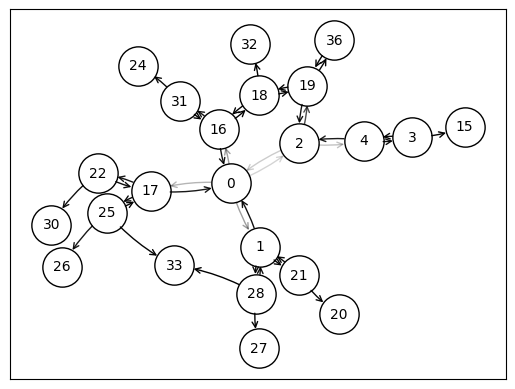

In [158]:
from torch_geometric.explain import Explainer, GNNExplainer

# 1. Define the Explainer
explainer = Explainer(
    model=trained_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='edge',
        return_type='log_probs',
    ),
)

# 2. Explain a specific edge (bond)
# Let's say we want to explain why Edge #? was predicted as a "Reaction Site"
edge_index_to_explain = 2
explanation = explainer(
    x=test_Dataset[mol_num].x,
    edge_index=test_Dataset[mol_num].edge_index,
    edge_attr=test_Dataset[mol_num].edge_attr,
    onroute=test_Dataset[mol_num].onroute,
    batch=test_Dataset[mol_num].batch,
    index=edge_index_to_explain,  # The index of the edge you want to explain
    target=test_Dataset[mol_num].edge_labels[edge_index_to_explain].unsqueeze(0)
)

# 3. Visualize
# This will plot the molecule and highlight the atoms/bonds that influenced the decision
#explanation.visualize_feature_importance(top_k=12)
explanation.visualize_graph()

In [159]:
edge_contribution = explanation.edge_mask.cpu().detach().numpy()
node_contribution = explanation.node_mask.cpu().detach().numpy() # If you used node masks

# Print influential bonds
print("--- Influential Bonds ---")
sorted_indices = edge_contribution.argsort()[::-1]
for idx in sorted_indices:
    score = edge_contribution[idx]
    # Map back to atom indices
    src = test_Dataset[mol_num].edge_index[0, idx].item()
    dst = test_Dataset[mol_num].edge_index[1, idx].item()
    print(f"Bond {src}-{dst}: Influence Score = {score:.4f}")

--- Influential Bonds ---
Bond 33-28: Influence Score = 0.8890
Bond 16-31: Influence Score = 0.8866
Bond 18-16: Influence Score = 0.8836
Bond 17-25: Influence Score = 0.8769
Bond 32-18: Influence Score = 0.8768
Bond 27-28: Influence Score = 0.8761
Bond 18-19: Influence Score = 0.8747
Bond 16-18: Influence Score = 0.8742
Bond 15-3: Influence Score = 0.8737
Bond 33-25: Influence Score = 0.8727
Bond 21-1: Influence Score = 0.8727
Bond 36-19: Influence Score = 0.8716
Bond 19-36: Influence Score = 0.8716
Bond 19-18: Influence Score = 0.8700
Bond 4-3: Influence Score = 0.8626
Bond 20-21: Influence Score = 0.8561
Bond 25-17: Influence Score = 0.8555
Bond 24-31: Influence Score = 0.8539
Bond 1-21: Influence Score = 0.8519
Bond 17-22: Influence Score = 0.8433
Bond 3-4: Influence Score = 0.8374
Bond 1-28: Influence Score = 0.8342
Bond 30-22: Influence Score = 0.8324
Bond 0-1: Influence Score = 0.8317
Bond 28-1: Influence Score = 0.8302
Bond 0-16: Influence Score = 0.8196
Bond 2-19: Influence Sco

In [160]:
pair_box = []
influence_box = []

turnexplain = 30

for kk in range(turnexplain):
    #edge_index_to_explain = 12
    if edge_index_to_explain % 2 == 1:
        raise Exception('Even number only!')
    explanation = explainer(
        x=test_Dataset[mol_num].x,
        edge_index=test_Dataset[mol_num].edge_index,
        edge_attr=test_Dataset[mol_num].edge_attr,
        onroute=test_Dataset[mol_num].onroute,
        batch=test_Dataset[mol_num].batch,
        index=edge_index_to_explain,  # The index of the edge you want to explain
        target=test_Dataset[mol_num].edge_labels[edge_index_to_explain].unsqueeze(0)
    )

    edge_contribution = explanation.edge_mask.cpu().detach().numpy()
    sorted_indices = edge_contribution.argsort()[::-1]
    if kk == 0:
        for idx in sorted_indices:
            score = edge_contribution[idx]
            src = test_Dataset[mol_num].edge_index[0, idx].item()
            dst = test_Dataset[mol_num].edge_index[1, idx].item()
            if {src, dst} in pair_box:
                for j in range(len(influence_box)):
                    #print({src, dst}, pair_box[j])
                    if {src, dst} == pair_box[j] and [src, dst] != [*pair_box[j]]:
                        influence_box[j] = influence_box[j] + score
            else:
                pair_box.append({src, dst})
                influence_box.append(score)
    else:
        for idx in sorted_indices:
            score = edge_contribution[idx]
            src = test_Dataset[mol_num].edge_index[0, idx].item()
            dst = test_Dataset[mol_num].edge_index[1, idx].item()
            for j in range(len(influence_box)):
                if {src, dst} == pair_box[j]:
                    influence_box[j] = influence_box[j] + score

    explanation = explainer(
        x=test_Dataset[mol_num].x,
        edge_index=test_Dataset[mol_num].edge_index,
        edge_attr=test_Dataset[mol_num].edge_attr,
        onroute=test_Dataset[mol_num].onroute,
        batch=test_Dataset[mol_num].batch,
        index=edge_index_to_explain,  # The index of the edge you want to explain
        target=test_Dataset[mol_num].edge_labels[edge_index_to_explain+1].unsqueeze(0)
    )

    edge_contribution = explanation.edge_mask.cpu().detach().numpy()
    sorted_indices = edge_contribution.argsort()[::-1]
    for idx in sorted_indices:
        score = edge_contribution[idx]
        src = test_Dataset[mol_num].edge_index[0, idx].item()
        dst = test_Dataset[mol_num].edge_index[1, idx].item()
        for j in range(len(influence_box)):
            if {src, dst} == pair_box[j]:
                influence_box[j] = influence_box[j] + score

for j, idx in enumerate(pair_box):
    print(f"Bond {pair_box[j]}: Influence Score = {influence_box[j] / turnexplain / 4}")

Bond {16, 18}: Influence Score = 0.8671523332595825
Bond {25, 17}: Influence Score = 0.8647204637527466
Bond {20, 21}: Influence Score = 0.42223748564720154
Bond {3, 4}: Influence Score = 0.8595353364944458
Bond {18, 19}: Influence Score = 0.8668047189712524
Bond {32, 18}: Influence Score = 0.43032342195510864
Bond {1, 28}: Influence Score = 0.8560346364974976
Bond {17, 22}: Influence Score = 0.8522636294364929
Bond {30, 22}: Influence Score = 0.4210857152938843
Bond {0, 1}: Influence Score = 0.6114356517791748
Bond {0, 17}: Influence Score = 0.5909492373466492
Bond {0, 16}: Influence Score = 0.583215057849884
Bond {16, 31}: Influence Score = 0.8450314998626709
Bond {1, 21}: Influence Score = 0.8440033793449402
Bond {33, 28}: Influence Score = 0.42358413338661194
Bond {2, 19}: Influence Score = 0.7175102829933167
Bond {19, 36}: Influence Score = 0.8443820476531982
Bond {3, 15}: Influence Score = 0.42882299423217773
Bond {25, 26}: Influence Score = 0.42728570103645325
Bond {24, 31}: Inf

In [184]:
0.1+0.9*0.42882299423217773

0.48594069480895996

In [ ]:
Bond {16, 1}: Influence Score = 0.7876083254814148